<a href="https://colab.research.google.com/github/JakubHus/climate-change-analysis/blob/main/ObszarRoboczySprawozdanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalacja niezbędnych bibliotek
!pip install xarray cfgrib eccodes
!pip install contextily
!pip install folium

In [ ]:
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import folium
import math
import pandas as pd
import cfgrib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress
from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm

In [ ]:
# Wczytanie danych chwilowych (stepType='instant') z pliku ERA5.grib
# Zmienne chwilowe: temperatura powietrza, punkt rosy, temperatura powierzchni, wiatr
ds_inst = xr.open_dataset(
    "ERA5.grib",
    engine="cfgrib",
    backend_kwargs={
        "filter_by_keys": {
            "stepType": "instant"
        }
    }
)

ds_inst

<xarray.Dataset> Size: 558kB
Dimensions:              (time: 8714, latitude: 1, longitude: 2)
Coordinates:
  * time                 (time) datetime64[ns] 70kB 2014-01-01T05:00:00 ... 2...
  * latitude             (latitude) float64 8B 53.0
  * longitude            (longitude) float64 16B 23.0 23.25
    number               int64 8B ...
    step                 timedelta64[ns] 8B ...
    depthBelowLandLayer  float64 8B ...
    valid_time           (time) datetime64[ns] 70kB ...
    surface              float64 8B ...
Data variables:
    swvl2                (time, latitude, longitude) float32 70kB ...
    t2m                  (time, latitude, longitude) float32 70kB ...
    u10                  (time, latitude, longitude) float32 70kB ...
    v10                  (time, latitude, longitude) float32 70kB ...
    d2m                  (time, latitude, longitude) float32 70kB ...
    skt                  (time, latitude, longitude) float32 70kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-06T01:53 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
# Wczytanie danych skumulowanych (stepType='accum') z pliku ERA5.grib
# Zmienne skumulowane: suma opadów (tp), promieniowanie (ssr), opady śniegu (sf)
ds_acc = xr.open_dataset(
    "ERA5.grib",
    engine="cfgrib",
    backend_kwargs={
        "filter_by_keys": {
            "stepType": "accum"
        }
    }
)

ds_acc

<xarray.Dataset> Size: 627kB
Dimensions:     (time: 8714, step: 2, latitude: 1, longitude: 2)
Coordinates:
  * time        (time) datetime64[ns] 70kB 2013-12-31T18:00:00 ... 2025-12-05...
  * step        (step) timedelta64[ns] 16B 06:00:00 11:00:00
  * latitude    (latitude) float64 8B 53.0
  * longitude   (longitude) float64 16B 23.0 23.25
    number      int64 8B ...
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 139kB ...
Data variables:
    tp          (time, step, latitude, longitude) float32 139kB ...
    ssr         (time, step, latitude, longitude) float32 139kB ...
    sf          (time, step, latitude, longitude) float32 139kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-06T01:53 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
# Weryfikacja zakresu czasowego obu zbiorów danych
time_min_inst = pd.to_datetime(ds_inst.time.min().values)
time_max_inst = pd.to_datetime(ds_inst.time.max().values)

print(f"Zakres czasowy danych:")
print(f"od: {time_min_inst}")
print(f"do: {time_max_inst}")

Zakres czasowy danych:
od: 2014-01-01 05:00:00
do: 2025-12-05 12:00:00


In [ ]:
time_min_acc = pd.to_datetime(ds_acc.valid_time.min().values)
time_max_acc = pd.to_datetime(ds_acc.valid_time.max().values)

print(f"Zakres czasowy danych:")
print(f"od: {time_min_acc}")
print(f"do: {time_max_acc}")

Zakres czasowy danych:
od: 2014-01-01 00:00:00
do: 2025-12-05 17:00:00


In [ ]:
# Wizualizacja przestrzenna
# Wybieramy szerokość i długość geograficzną dla naszego zbioru danych
lats = ds_acc.latitude.values
lons = ds_acc.longitude.values

# Tworzymy punkty
points = [Point(lon, lat) for lat in lats for lon in lons]

# Tworzymy geodataframe ze stworzonymi punktami
gdf = gpd.GeoDataFrame(geometry=points)
gdf.set_crs(epsg=4326, inplace=True)

# Obliczamy centroid dla punktów na mapie, który posłuży do początkowego jej wyświetlania
center_lat = gdf.geometry.y.mean()
center_lon = gdf.geometry.x.mean()

# Tworzenie mapy
m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# Obliczono odległości między punktami
lat_res = abs(gdf.geometry.y[1] - gdf.geometry.y[0])
lon_res = abs(gdf.geometry.x[1] - gdf.geometry.x[0])

# Tworzymy poligon (z punktów) o określonym promieniu
for point in gdf.geometry:
    radius_lat = 0.5 * 111_000 * lat_res
    radius_lon = 0.5 * 111_000 * lon_res * math.cos(math.radians(point.y))
    radius_m = (radius_lat + radius_lon)

    folium.Circle(
        location=[point.y, point.x],
        radius=radius_m,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.3,
        opacity=0.5
    ).add_to(m)

m

**Opis dostępnych danych:**  


*   `swvl2` - Objętościowa wilgotność gleby w drugiej warstwie, zakres warstwy: 7–28 cm
*   `t2m` - Temperatura powietrza na wysokości 2 m nad powierzchnią gruntu [K]
*   `u10` - Składowa zachód–wschód wiatru na wysokości 10 m (dodatnia - wiatr wieje na wschód, ujemna - na zachód) [m/s]
*   `v10` - Składowa południe–północ wiatru na wysokości 10 m (dodatnia - wiatr wieje na północ, ujemna - na południe) [m/s]
*   `d2m` - Temperatura punktu rosy na wysokości 2 m [K]
*   `skt` - Temperatura „skóry” powierzchni (gruntu, wody, lodu) [K]

*   `tp` - Całkowita suma opadu (deszcz + śnieg) w danym kroku czasowym [m]
*   `ssr` - Całkowita energia promieniowania słonecznego docierająca do powierzchni w danym kroku czasowym [J/m^2]
*   `sf` - Opad śniegu wyrażony jako równoważnik wody w danym kroku czasowym [m]


In [ ]:
# Sprawdzenie czy czas rośnie monotonicznie
print(ds_inst.time.to_index().is_monotonic_increasing)
print(ds_acc.time.to_index().is_monotonic_increasing)

True
True


In [ ]:
# Sprawdzenie wymiarów dla obu zbiorów
print(ds_inst.dims)
print(ds_acc.dims)

FrozenMappingWarningOnValuesAccess({'time': 8714, 'latitude': 1, 'longitude': 2})
FrozenMappingWarningOnValuesAccess({'time': 8714, 'step': 2, 'latitude': 1, 'longitude': 2})


In [ ]:
# Sprawdzenie zmiennych
print(ds_inst.data_vars)
print(ds_acc.data_vars)

Data variables:
    swvl2    (time, latitude, longitude) float32 70kB ...
    t2m      (time, latitude, longitude) float32 70kB ...
    u10      (time, latitude, longitude) float32 70kB ...
    v10      (time, latitude, longitude) float32 70kB ...
    d2m      (time, latitude, longitude) float32 70kB ...
    skt      (time, latitude, longitude) float32 70kB ...
Data variables:
    tp       (time, step, latitude, longitude) float32 139kB ...
    ssr      (time, step, latitude, longitude) float32 139kB ...
    sf       (time, step, latitude, longitude) float32 139kB ...


In [ ]:
# Ekstrakcja danych dla dwóch punktów gridowych (~53°N 23°E i ~53°N 23.25°E)
# Konwersja zbiorów xarray do pandas DataFrame

points = [(53.0, 23.0), (53.0, 23.25)]

ds_inst_sel = ds_inst.sel(latitude=[p[0] for p in points],
                          longitude=[p[1] for p in points],
                          method="nearest")

ds_acc_sel = ds_acc.sel(latitude=[p[0] for p in points],
                        longitude=[p[1] for p in points],
                        method="nearest")

df_inst = ds_inst_sel.to_dataframe().reset_index()
df_acc = ds_acc_sel.to_dataframe().reset_index()

df_inst = df_inst.drop_duplicates().reset_index(drop=True)
df_acc  = df_acc.drop_duplicates().reset_index(drop=True)

In [ ]:
df_inst.head()

,time,latitude,longitude,number,step,depthBelowLandLayer,valid_time,swvl2,surface,t2m,u10,v10,d2m,skt
0,2014-01-01 05:00:00,53.0,23.00,0,0 days,7.0,2014-01-01 05:00:00,0.350735,0.0,273.902100,-2.567245,3.717880,272.403320,273.650238
1,2014-01-01 05:00:00,53.0,23.25,0,0 days,7.0,2014-01-01 05:00:00,0.281963,0.0,273.689209,-2.526230,3.800888,272.260742,273.570160
2,2014-01-01 12:00:00,53.0,23.00,0,0 days,7.0,2014-01-01 12:00:00,0.350016,0.0,274.357544,-2.243820,3.337830,272.659302,275.305908
3,2014-01-01 12:00:00,53.0,23.25,0,0 days,7.0,2014-01-01 12:00:00,0.281199,0.0,274.187622,-2.313156,3.368103,272.598755,275.079346
4,2014-01-02 05:00:00,53.0,23.00,0,0 days,7.0,2014-01-02 05:00:00,0.348981,0.0,274.251892,-1.293732,2.775955,274.248932,274.145844


In [ ]:
df_acc.head()

,time,step,latitude,longitude,number,surface,valid_time,tp,ssr,sf
0,2013-12-31 18:00:00,0 days 06:00:00,53.0,23.00,0,0.0,2014-01-01 00:00:00,NaN,NaN,NaN
1,2013-12-31 18:00:00,0 days 06:00:00,53.0,23.25,0,0.0,2014-01-01 00:00:00,NaN,NaN,NaN
2,2013-12-31 18:00:00,0 days 11:00:00,53.0,23.00,0,0.0,2014-01-01 05:00:00,0.000000e+00,3.599999e-12,3.576279e-07
3,2013-12-31 18:00:00,0 days 11:00:00,53.0,23.25,0,0.0,2014-01-01 05:00:00,9.536743e-07,3.599999e-12,5.960464e-07
4,2014-01-01 06:00:00,0 days 06:00:00,53.0,23.00,0,0.0,2014-01-01 12:00:00,1.430511e-06,1.811840e+05,0.000000e+00


In [ ]:
# Podstawowe informacje o dataframes
df_inst.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17428 entries, 0 to 17427
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype          
---  ------               --------------  -----          
 0   time                 17428 non-null  datetime64[ns] 
 1   latitude             17428 non-null  float64        
 2   longitude            17428 non-null  float64        
 3   number               17428 non-null  int64          
 4   step                 17428 non-null  timedelta64[ns]
 5   depthBelowLandLayer  17428 non-null  float64        
 6   valid_time           17428 non-null  datetime64[ns] 
 7   swvl2                17428 non-null  float32        
 8   surface              17428 non-null  float64        
 9   t2m                  17428 non-null  float32        
 10  u10                  17428 non-null  float32        
 11  v10                  17428 non-null  float32        
 12  d2m                  17428 non-null  float32        
 13  skt             

In [ ]:
df_acc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34856 entries, 0 to 34855
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   time        34856 non-null  datetime64[ns] 
 1   step        34856 non-null  timedelta64[ns]
 2   latitude    34856 non-null  float64        
 3   longitude   34856 non-null  float64        
 4   number      34856 non-null  int64          
 5   surface     34856 non-null  float64        
 6   valid_time  34856 non-null  datetime64[ns] 
 7   tp          17428 non-null  float32        
 8   ssr         17428 non-null  float32        
 9   sf          17428 non-null  float32        
dtypes: datetime64[ns](2), float32(3), float64(3), int64(1), timedelta64[ns](1)
memory usage: 2.3 MB


In [ ]:
# Podstawowe statystyki dla dataframes
df_inst.describe()

,time,latitude,longitude,number,step,depthBelowLandLayer,valid_time,swvl2,surface,t2m,u10,v10,d2m,skt
count,17428,17428.0,17428.000000,17428.0,17428,17428.0,17428,17428.000000,17428.0,17428.000000,17428.000000,17428.000000,17428.000000,17428.000000
mean,2019-12-19 08:30:00,53.0,23.125000,0.0,0 days 00:00:00,7.0,2019-12-19 08:30:00,0.273879,0.0,282.860352,0.788042,0.502790,277.965332,283.686249
min,2014-01-01 05:00:00,53.0,23.000000,0.0,0 days 00:00:00,7.0,2014-01-01 05:00:00,0.070086,0.0,250.319229,-8.098633,-9.190063,248.032211,248.398392
25%,2016-12-25 05:00:00,53.0,23.000000,0.0,0 days 00:00:00,7.0,2016-12-25 05:00:00,0.225226,0.0,275.422607,-1.541142,-1.285568,272.834480,275.493553
50%,2019-12-19 08:30:00,53.0,23.125000,0.0,0 days 00:00:00,7.0,2019-12-19 08:30:00,0.280450,0.0,282.303833,0.757309,0.651199,277.977524,283.033188
75%,2022-12-12 12:00:00,53.0,23.250000,0.0,0 days 00:00:00,7.0,2022-12-12 12:00:00,0.329267,0.0,289.998505,3.024372,2.343948,283.859261,291.258942
max,2025-12-05 12:00:00,53.0,23.250000,0.0,0 days 00:00:00,7.0,2025-12-05 12:00:00,0.424994,0.0,309.033264,12.497284,9.312988,295.065582,314.150940
std,NaN,0.0,0.125004,0.0,0 days 00:00:00,0.0,NaN,0.070073,0.0,9.308957,3.040214,2.492831,7.442955,10.042123


In [ ]:
df_acc.describe()

,time,step,latitude,longitude,number,surface,valid_time,tp,ssr,sf
count,34856,34856,34856.0,34856.000000,34856.0,34856.0,34856,1.742800e+04,1.742800e+04,17428.000000
mean,2019-12-19 00:00:00,0 days 08:30:00,53.0,23.125000,0.0,0.0,2019-12-19 08:30:00,8.855986e-05,6.211337e+05,0.000009
min,2013-12-31 18:00:00,0 days 06:00:00,53.0,23.000000,0.0,0.0,2014-01-01 00:00:00,0.000000e+00,3.599999e-12,0.000000
25%,2016-12-24 18:00:00,0 days 06:00:00,53.0,23.000000,0.0,0.0,2016-12-25 03:45:00,0.000000e+00,2.803200e+04,0.000000
50%,2019-12-19 00:00:00,0 days 08:30:00,53.0,23.125000,0.0,0.0,2019-12-19 08:30:00,9.536743e-07,3.606080e+05,0.000000
75%,2022-12-12 06:00:00,0 days 11:00:00,53.0,23.250000,0.0,0.0,2022-12-12 13:15:00,3.623962e-05,1.015600e+06,0.000000
max,2025-12-05 06:00:00,0 days 11:00:00,53.0,23.250000,0.0,0.0,2025-12-05 17:00:00,1.126003e-02,2.535552e+06,0.001694
std,NaN,0 days 02:30:00.129105371,0.0,0.125002,0.0,0.0,NaN,3.160989e-04,6.898789e+05,0.000067


In [ ]:
# Analiza braków danych
print(df_inst.isnull().sum())
print(df_acc.isnull().sum())

time                   0
latitude               0
longitude              0
number                 0
step                   0
depthBelowLandLayer    0
valid_time             0
swvl2                  0
surface                0
t2m                    0
u10                    0
v10                    0
d2m                    0
skt                    0
dtype: int64
time              0
step              0
latitude          0
longitude         0
number            0
surface           0
valid_time        0
tp            17428
ssr           17428
sf            17428
dtype: int64


In [ ]:
# Usunięcie wartości brakujących, które nie przynoszą żadnych informacji i nie da się ich uzupełnić
df_acc.dropna(inplace=True)
df_acc.head()

,time,step,latitude,longitude,number,surface,valid_time,tp,ssr,sf
2,2013-12-31 18:00:00,0 days 11:00:00,53.0,23.00,0,0.0,2014-01-01 05:00:00,0.000000e+00,3.599999e-12,3.576279e-07
3,2013-12-31 18:00:00,0 days 11:00:00,53.0,23.25,0,0.0,2014-01-01 05:00:00,9.536743e-07,3.599999e-12,5.960464e-07
4,2014-01-01 06:00:00,0 days 06:00:00,53.0,23.00,0,0.0,2014-01-01 12:00:00,1.430511e-06,1.811840e+05,0.000000e+00
5,2014-01-01 06:00:00,0 days 06:00:00,53.0,23.25,0,0.0,2014-01-01 12:00:00,4.768372e-07,1.800960e+05,0.000000e+00
10,2014-01-01 18:00:00,0 days 11:00:00,53.0,23.00,0,0.0,2014-01-02 05:00:00,3.623962e-05,3.599999e-12,2.264977e-06


In [ ]:
# Sprawdzanie poprawności danych
print(df_inst["t2m"].between(231, 315).all())
print(df_inst["d2m"].between(231, 315).all())
print(df_inst["skt"].between(231, 315).all())

print((df_acc["tp"] >= 0).all())
print((df_acc["ssr"] >= 0).all())
print((df_acc["sf"] >= 0).all())

True
True
True
True
True
True


In [ ]:
# Zamiana [K] na [℃], [m] na [mm] oraz [J/m^2] na [J/mm^2]
cols = ["t2m", "d2m", "skt"]
df_inst[cols] = df_inst[cols] - 273.15

cols = ["tp", "sf"]
df_acc[cols] = df_acc[cols] * 1000

cols = ["ssr"]
df_acc[cols] = df_acc[cols] * 1e-6

In [ ]:
df_inst.describe()

,time,latitude,longitude,number,step,depthBelowLandLayer,valid_time,swvl2,surface,t2m,u10,v10,d2m,skt
count,17428,17428.0,17428.000000,17428.0,17428,17428.0,17428,17428.000000,17428.0,17428.000000,17428.000000,17428.000000,17428.000000,17428.000000
mean,2019-12-19 08:30:00,53.0,23.125000,0.0,0 days 00:00:00,7.0,2019-12-19 08:30:00,0.273879,0.0,9.710365,0.788042,0.502790,4.815344,10.536272
min,2014-01-01 05:00:00,53.0,23.000000,0.0,0 days 00:00:00,7.0,2014-01-01 05:00:00,0.070086,0.0,-22.830765,-8.098633,-9.190063,-25.117783,-24.751602
25%,2016-12-25 05:00:00,53.0,23.000000,0.0,0 days 00:00:00,7.0,2016-12-25 05:00:00,0.225226,0.0,2.272614,-1.541142,-1.285568,-0.315514,2.343559
50%,2019-12-19 08:30:00,53.0,23.125000,0.0,0 days 00:00:00,7.0,2019-12-19 08:30:00,0.280450,0.0,9.153839,0.757309,0.651199,4.827530,9.883194
75%,2022-12-12 12:00:00,53.0,23.250000,0.0,0 days 00:00:00,7.0,2022-12-12 12:00:00,0.329267,0.0,16.848511,3.024372,2.343948,10.709267,18.108948
max,2025-12-05 12:00:00,53.0,23.250000,0.0,0 days 00:00:00,7.0,2025-12-05 12:00:00,0.424994,0.0,35.883270,12.497284,9.312988,21.915588,41.000946
std,NaN,0.0,0.125004,0.0,0 days 00:00:00,0.0,NaN,0.070073,0.0,9.308961,3.040214,2.492831,7.442954,10.042125


In [ ]:
df_acc.describe()

,time,step,latitude,longitude,number,surface,valid_time,tp,ssr,sf
count,17428,17428,17428.0,17428.000000,17428.0,17428.0,17428,17428.000000,1.742800e+04,17428.000000
mean,2019-12-19 00:00:00,0 days 08:30:00,53.0,23.125000,0.0,0.0,2019-12-19 08:30:00,0.088560,6.211336e-01,0.009460
min,2013-12-31 18:00:00,0 days 06:00:00,53.0,23.000000,0.0,0.0,2014-01-01 05:00:00,0.000000,3.599999e-18,0.000000
25%,2016-12-24 18:00:00,0 days 06:00:00,53.0,23.000000,0.0,0.0,2016-12-25 05:00:00,0.000000,2.803200e-02,0.000000
50%,2019-12-19 00:00:00,0 days 08:30:00,53.0,23.125000,0.0,0.0,2019-12-19 08:30:00,0.000954,3.606080e-01,0.000000
75%,2022-12-12 06:00:00,0 days 11:00:00,53.0,23.250000,0.0,0.0,2022-12-12 12:00:00,0.036240,1.015600e+00,0.000000
max,2025-12-05 06:00:00,0 days 11:00:00,53.0,23.250000,0.0,0.0,2025-12-05 12:00:00,11.260033,2.535552e+00,1.694322
std,NaN,0 days 02:30:00.258216299,0.0,0.125004,0.0,0.0,NaN,0.316093,6.898644e-01,0.066647


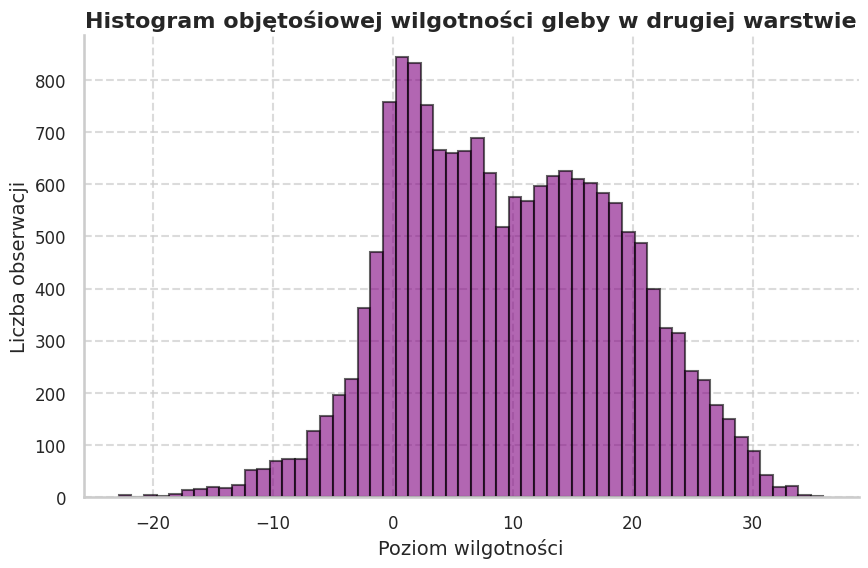

In [ ]:
# Badanie rozkładów zmiennych

sns.set_style("whitegrid")
sns.set_context("talk")
plt.figure(figsize=(10,6))

plt.hist(df_inst["t2m"], bins=56,
         color="purple",
         alpha=0.6,
         edgecolor="black")

plt.xlabel("Poziom wilgotności", fontsize=14)
plt.ylabel("Liczba obserwacji", fontsize=14)
plt.title("Histogram objętośiowej wilgotności gleby w drugiej warstwie", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()

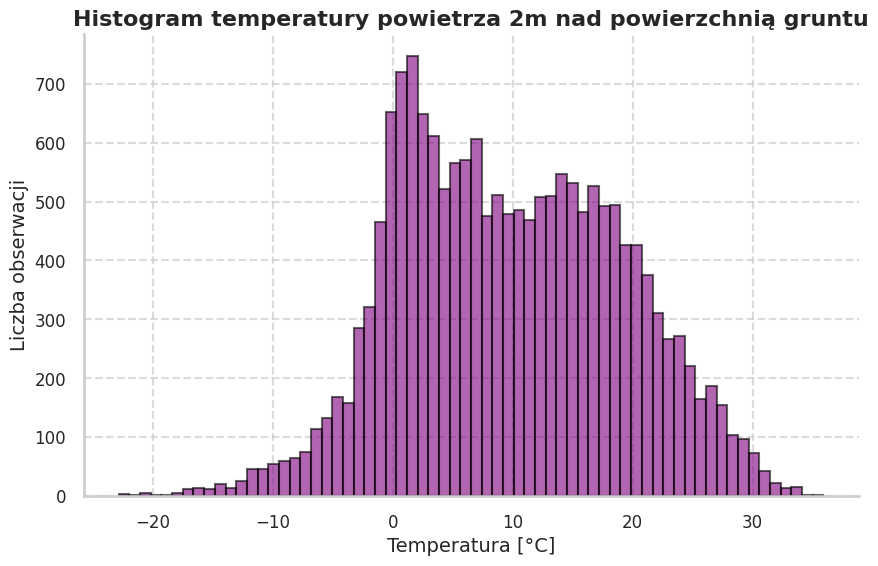

In [ ]:
sns.set_style("whitegrid")
sns.set_context("talk")
plt.figure(figsize=(10,6))

plt.hist(df_inst["t2m"], bins=66,
         color="purple",
         alpha=0.6,
         edgecolor="black")

plt.xlabel("Temperatura [°C]", fontsize=14)
plt.ylabel("Liczba obserwacji", fontsize=14)
plt.title("Histogram temperatury powietrza 2m nad powierzchnią gruntu", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()

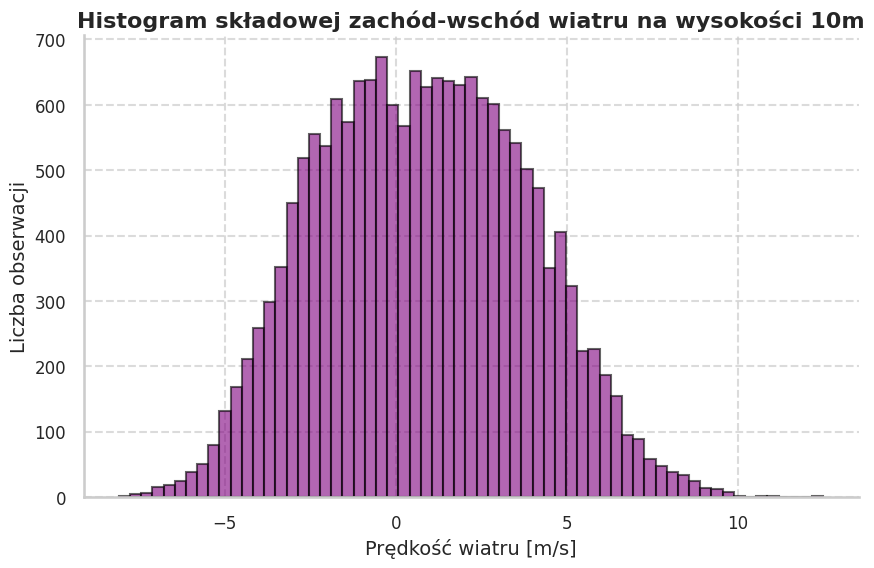

In [ ]:
sns.set_style("whitegrid")
sns.set_context("talk")
plt.figure(figsize=(10,6))

plt.hist(df_inst["u10"], bins=63,
         color="purple",
         alpha=0.6,
         edgecolor="black")

plt.xlabel("Prędkość wiatru [m/s]", fontsize=14)
plt.ylabel("Liczba obserwacji", fontsize=14)
plt.title("Histogram składowej zachód-wschód wiatru na wysokości 10m", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()

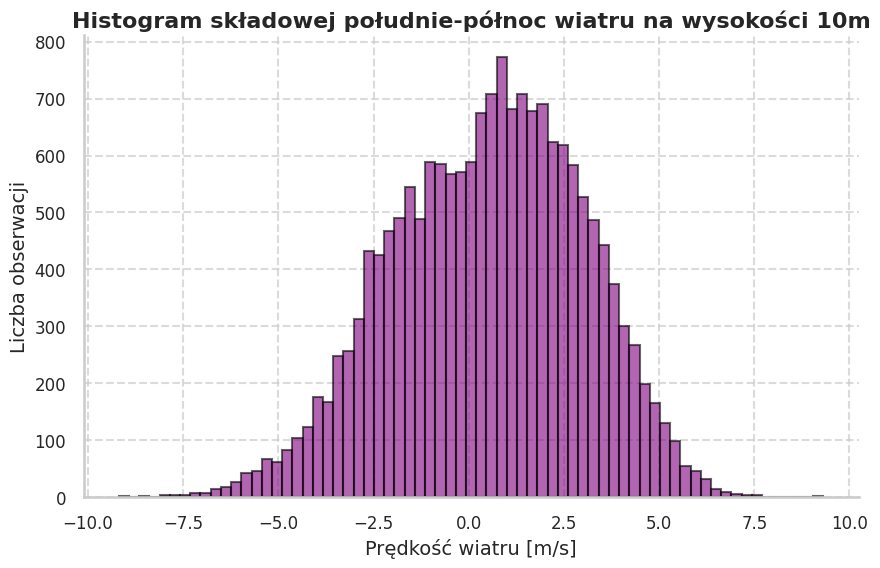

In [ ]:
sns.set_style("whitegrid")
sns.set_context("talk")
plt.figure(figsize=(10,6))

plt.hist(df_inst["v10"], bins=69,
         color="purple",
         alpha=0.6,
         edgecolor="black")

plt.xlabel("Prędkość wiatru [m/s]", fontsize=14)
plt.ylabel("Liczba obserwacji", fontsize=14)
plt.title("Histogram składowej południe-północ wiatru na wysokości 10m", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()

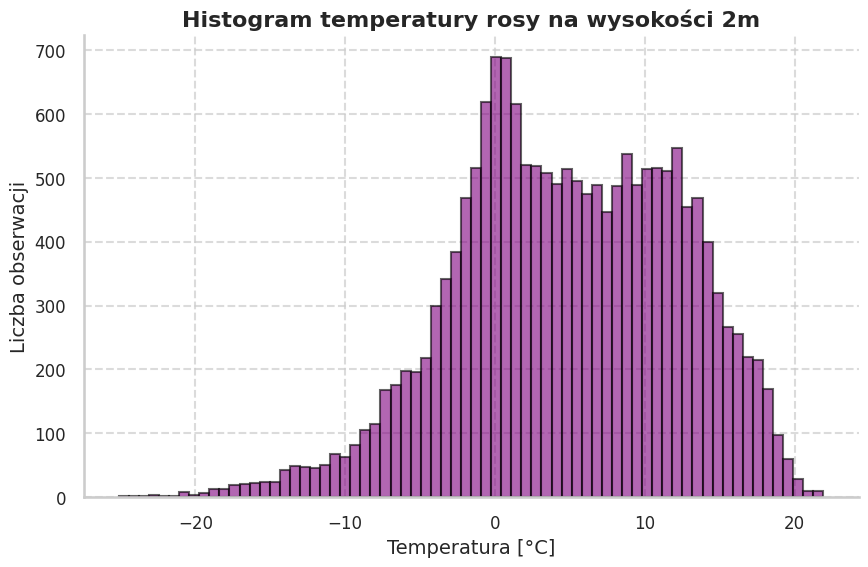

In [ ]:
sns.set_style("whitegrid")
sns.set_context("talk")
plt.figure(figsize=(10,6))

plt.hist(df_inst["d2m"], bins=70,
         color="purple",
         alpha=0.6,
         edgecolor="black")

plt.xlabel("Temperatura [°C]", fontsize=14)
plt.ylabel("Liczba obserwacji", fontsize=14)
plt.title("Histogram temperatury rosy na wysokości 2m", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()

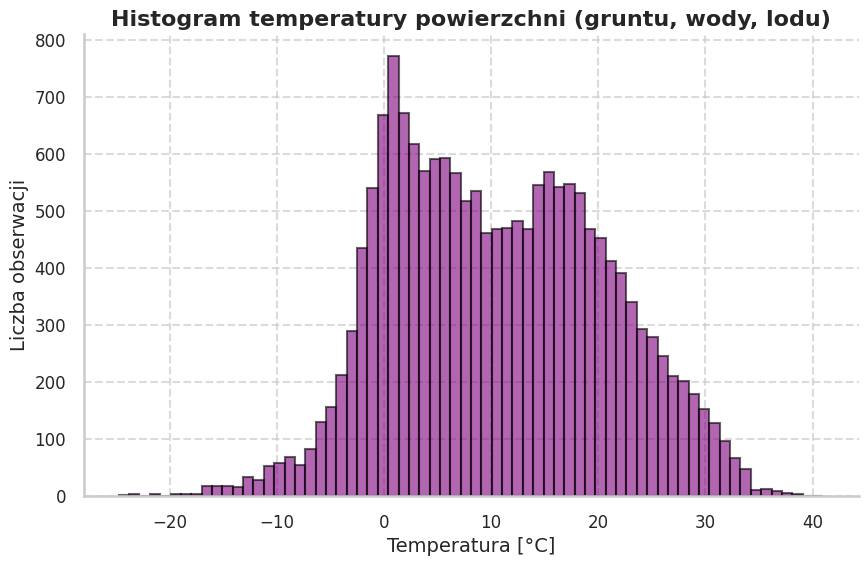

In [ ]:
sns.set_style("whitegrid")
sns.set_context("talk")
plt.figure(figsize=(10,6))

plt.hist(df_inst["skt"], bins=68,
         color="purple",
         alpha=0.6,
         edgecolor="black")

plt.xlabel("Temperatura [°C]", fontsize=14)
plt.ylabel("Liczba obserwacji", fontsize=14)
plt.title("Histogram temperatury powierzchni (gruntu, wody, lodu)", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()

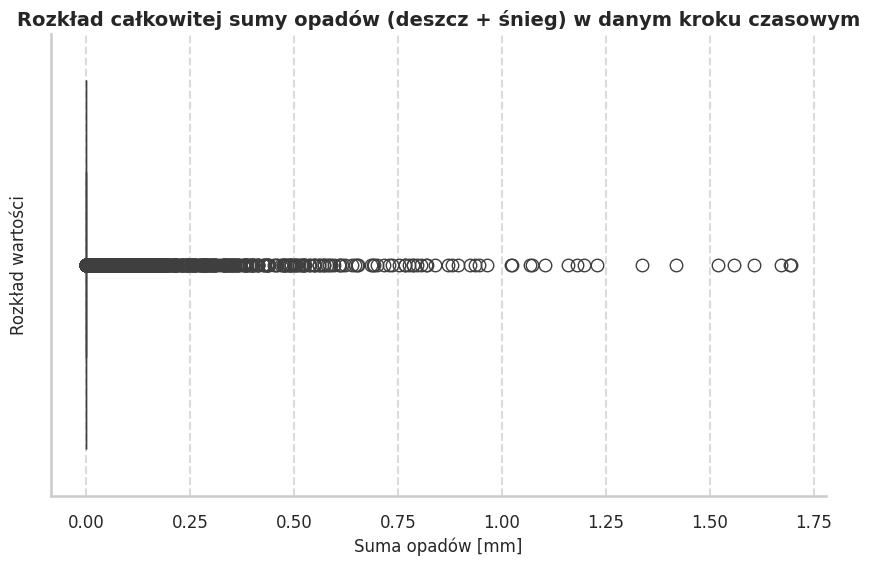

In [ ]:
sns.set_style("whitegrid")
sns.set_context("talk")
plt.figure(figsize=(10,6))

sns.boxplot(x=df_acc["sf"])

plt.xlabel("Suma opadów [mm]", fontsize=12)
plt.ylabel("Rozkład wartości", fontsize=12)
plt.title("Rozkład całkowitej sumy opadów (deszcz + śnieg) w danym kroku czasowym", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine()
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()

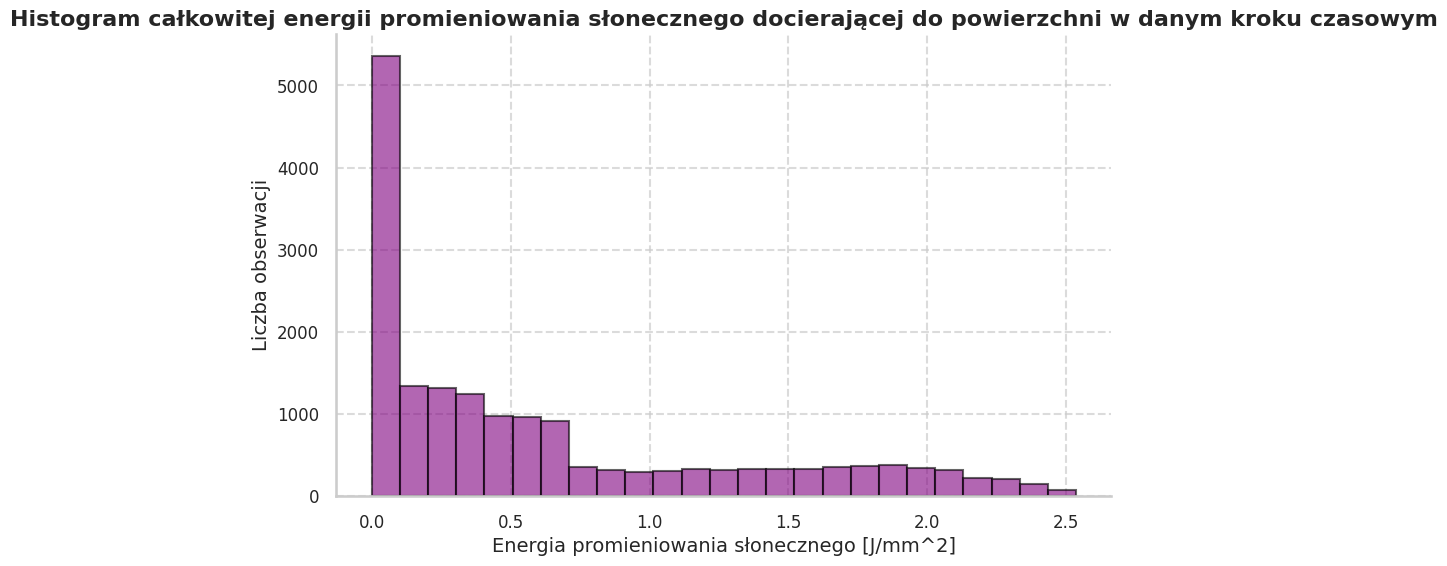

In [ ]:
sns.set_style("whitegrid")
sns.set_context("talk")
plt.figure(figsize=(10,6))

plt.hist(df_acc['ssr'], bins=25,
         color="purple",
         alpha=0.6,
         edgecolor="black")

plt.xlabel("Energia promieniowania słonecznego [J/mm^2]", fontsize=14)
plt.ylabel("Liczba obserwacji", fontsize=14)
plt.title("Histogram całkowitej energii promieniowania słonecznego docierającej do powierzchni w danym kroku czasowym", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()

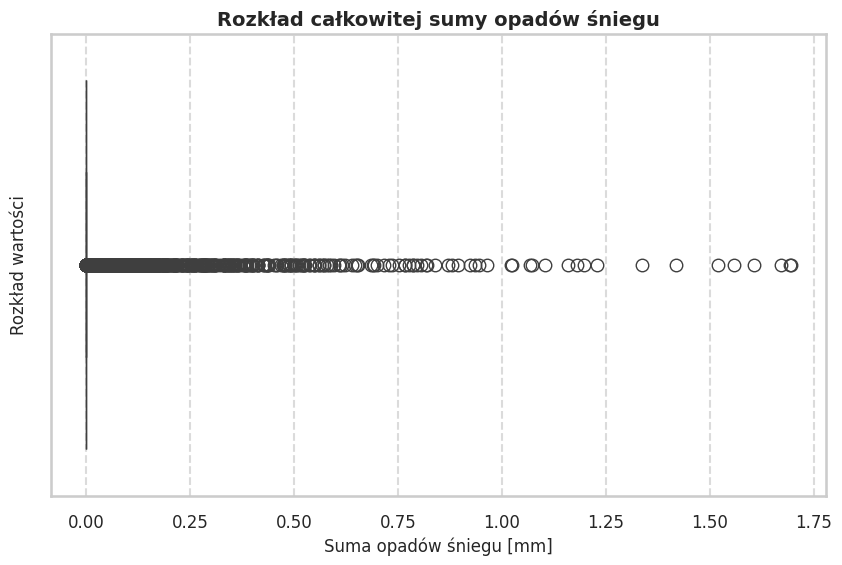

In [ ]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

sns.boxplot(x=df_acc["sf"])

plt.xlabel("Suma opadów śniegu [mm]", fontsize=12)
plt.ylabel("Rozkład wartości", fontsize=12)
plt.title("Rozkład całkowitej sumy opadów śniegu", fontsize=14, fontweight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
df_inst["time"].agg(["min", "max"])

,time
min,2014-01-01 05:00:00
max,2025-12-05 12:00:00


In [ ]:
df_acc["valid_time"].agg(["min", "max"])


,valid_time
min,2014-01-01 05:00:00
max,2025-12-05 12:00:00


In [ ]:
df_inst["time"].is_unique
df_acc["valid_time"].is_unique

False

In [ ]:
# Dla każdego dnia po 4 obserwacje
# Zgadza się, bo obserwacje są dla dwóch punktów i dwa razy dziennie
df_inst.groupby(df_inst["time"].dt.date).size()

,0
time,
2014-01-01,4
2014-01-02,4
2014-01-03,4
2014-01-04,4
2014-01-05,4
...,...
2025-12-01,4
2025-12-02,4
2025-12-03,4


In [ ]:
# Dla każdego dnia po 4 obserwacje
# Zgadza się, bo obserwacje są dla dwóch punktów i dwa razy dziennie
df_inst.groupby(df_acc["valid_time"].dt.date).size()

,0
valid_time,
2014-01-01,4
2014-01-02,4
2014-01-03,4
2014-01-04,4
2014-01-05,4
...,...
2019-12-15,4
2019-12-16,4
2019-12-17,4


In [ ]:
# Dodanie obliczonej prędkości wiatru do df_inst
df_inst["wind_speed"] = np.sqrt(df_inst["u10"]**2 + df_inst["v10"]**2)
df_inst.head(5)

,time,latitude,longitude,number,step,depthBelowLandLayer,valid_time,swvl2,surface,t2m,u10,v10,d2m,skt,wind_speed
0,2014-01-01 05:00:00,53.0,23.00,0,0 days,7.0,2014-01-01 05:00:00,0.350735,0.0,0.752106,-2.567245,3.717880,-0.746674,0.500244,4.518117
1,2014-01-01 05:00:00,53.0,23.25,0,0 days,7.0,2014-01-01 05:00:00,0.281963,0.0,0.539215,-2.526230,3.800888,-0.889252,0.420166,4.563835
2,2014-01-01 12:00:00,53.0,23.00,0,0 days,7.0,2014-01-01 12:00:00,0.350016,0.0,1.207550,-2.243820,3.337830,-0.490692,2.155914,4.021919
3,2014-01-01 12:00:00,53.0,23.25,0,0 days,7.0,2014-01-01 12:00:00,0.281199,0.0,1.037628,-2.313156,3.368103,-0.551239,1.929352,4.085928
4,2014-01-02 05:00:00,53.0,23.00,0,0 days,7.0,2014-01-02 05:00:00,0.348981,0.0,1.101898,-1.293732,2.775955,1.098938,0.995850,3.062624


In [ ]:
# Utworzono kolumny pomocnicze do agregacji
df_inst["date"] = df_inst["time"].dt.date
df_inst["year"] = df_inst["time"].dt.year
df_inst["month"] = df_inst["time"].dt.month
df_inst["hour"] = df_inst["time"].dt.hour

cols = ['time', 'latitude', 'longitude', 'valid_time', 'swvl2', 't2m', 'u10', 'v10', 'd2m', 'skt', 'wind_speed', 'date', 'year', 'month', 'hour']
df_sel = df_inst[cols]

df_inst.head()

,time,latitude,longitude,number,step,depthBelowLandLayer,valid_time,swvl2,surface,t2m,u10,v10,d2m,skt,wind_speed,date,year,month,hour
0,2014-01-01 05:00:00,53.0,23.00,0,0 days,7.0,2014-01-01 05:00:00,0.350735,0.0,0.752106,-2.567245,3.717880,-0.746674,0.500244,4.518117,2014-01-01,2014,1,5
1,2014-01-01 05:00:00,53.0,23.25,0,0 days,7.0,2014-01-01 05:00:00,0.281963,0.0,0.539215,-2.526230,3.800888,-0.889252,0.420166,4.563835,2014-01-01,2014,1,5
2,2014-01-01 12:00:00,53.0,23.00,0,0 days,7.0,2014-01-01 12:00:00,0.350016,0.0,1.207550,-2.243820,3.337830,-0.490692,2.155914,4.021919,2014-01-01,2014,1,12
3,2014-01-01 12:00:00,53.0,23.25,0,0 days,7.0,2014-01-01 12:00:00,0.281199,0.0,1.037628,-2.313156,3.368103,-0.551239,1.929352,4.085928,2014-01-01,2014,1,12
4,2014-01-02 05:00:00,53.0,23.00,0,0 days,7.0,2014-01-02 05:00:00,0.348981,0.0,1.101898,-1.293732,2.775955,1.098938,0.995850,3.062624,2014-01-02,2014,1,5


In [ ]:
# Utworzono kolumny pomocnicze do agregacji
df_acc["date"] = df_acc["valid_time"].dt.date
df_acc["year"] = df_acc["valid_time"].dt.year
df_acc["month"] = df_acc["valid_time"].dt.month
df_acc["hour"] = df_acc["valid_time"].dt.hour

cols = ['time', 'step', 'latitude', 'longitude', 'valid_time', 'tp', 'ssr', 'sf', 'date', 'year', 'month', 'hour']
df_sel = df_acc[cols]

df_acc.head()

,time,step,latitude,longitude,number,surface,valid_time,tp,ssr,sf,date,year,month,hour
2,2013-12-31 18:00:00,0 days 11:00:00,53.0,23.00,0,0.0,2014-01-01 05:00:00,0.000000,3.599999e-18,0.000358,2014-01-01,2014,1,5
3,2013-12-31 18:00:00,0 days 11:00:00,53.0,23.25,0,0.0,2014-01-01 05:00:00,0.000954,3.599999e-18,0.000596,2014-01-01,2014,1,5
4,2014-01-01 06:00:00,0 days 06:00:00,53.0,23.00,0,0.0,2014-01-01 12:00:00,0.001431,1.811840e-01,0.000000,2014-01-01,2014,1,12
5,2014-01-01 06:00:00,0 days 06:00:00,53.0,23.25,0,0.0,2014-01-01 12:00:00,0.000477,1.800960e-01,0.000000,2014-01-01,2014,1,12
10,2014-01-01 18:00:00,0 days 11:00:00,53.0,23.00,0,0.0,2014-01-02 05:00:00,0.036240,3.599999e-18,0.002265,2014-01-02,2014,1,5


In [ ]:
# Sprawdzenie poprawności przekształceń
print("df_inst: zakres czasu:", df_inst["valid_time"].min(), "->", df_inst["valid_time"].max())
print("df_acc : zakres czasu:", df_acc["valid_time"].min(),  "->", df_acc["valid_time"].max())

print("df_inst: unikalne godziny:", sorted(df_inst["hour"].dropna().unique()))
print("df_acc : unikalne godziny:", sorted(df_acc["hour"].dropna().unique()))

df_inst: zakres czasu: 2014-01-01 05:00:00 -> 2025-12-05 12:00:00
df_acc : zakres czasu: 2014-01-01 05:00:00 -> 2025-12-05 12:00:00
df_inst: unikalne godziny: [np.int32(5), np.int32(12)]
df_acc : unikalne godziny: [np.int32(5), np.int32(12)]


In [ ]:
# Tworzenie krotki z współrzędnych
df_inst["point_id"] = list(zip(df_inst["latitude"], df_inst["longitude"]))
df_acc["point_id"] = list(zip(df_acc["latitude"], df_acc["longitude"]))

print("Punkty w df_inst:", df_inst["point_id"].unique())
print("Punkty w df_acc :", df_acc["point_id"].unique())

Punkty w df_inst: [(53.0, 23.0) (53.0, 23.25)]
Punkty w df_acc : [(53.0, 23.0) (53.0, 23.25)]


In [ ]:
# Agregacja dobowa dla każdego punktu: średnia z dostępnych godzin

# Timestamp dobowy do grupowania
df_inst["date_ts"] = df_inst["time"].dt.floor("D")

# Agregacja dobowa na punkt (średnia z 05 i 12 dla danego punktu)
daily_point = (
    df_inst
    .groupby(["date_ts", "point_id"], as_index=False)
    .agg(
        t2m_day_point=("t2m", "mean"),
        d2m_day_point=("d2m", "mean"),
        skt_day_point=("skt", "mean"),
        swvl2_day_point=("swvl2", "mean"),
        n_obs=("hour", "count")
    )
)

daily_point.head()

,date_ts,point_id,t2m_day_point,d2m_day_point,skt_day_point,swvl2_day_point,n_obs
0,2014-01-01,"(53.0, 23.0)",0.979828,-0.618683,1.328079,0.350375,2
1,2014-01-01,"(53.0, 23.25)",0.788422,-0.720245,1.174759,0.281581,2
2,2014-01-02,"(53.0, 23.0)",1.495758,1.003830,1.719772,0.348864,2
3,2014-01-02,"(53.0, 23.25)",1.329742,0.809494,1.657272,0.280092,2
4,2014-01-03,"(53.0, 23.0)",1.436905,0.628250,1.320648,0.347978,2


In [ ]:
# Agregacja przestrzenna: średnia z dwóch punktów -> jedna doba dla obszaru
daily_area = (
    daily_point
    .groupby("date_ts", as_index=False)
    .agg(
        t2m_day=("t2m_day_point", "mean"),
        d2m_day=("d2m_day_point", "mean"),
        skt_day=("skt_day_point", "mean"),
        swvl2_day=("swvl2_day_point", "mean"),
        n_points=("point_id", "nunique")
    )
)

# Dodanie roku i miesiąca
daily_area["year"] = daily_area["date_ts"].dt.year
daily_area["month"] = daily_area["date_ts"].dt.month

daily_area.head()

,date_ts,t2m_day,d2m_day,skt_day,swvl2_day,n_points,year,month
0,2014-01-01,0.884125,-0.669464,1.251419,0.315978,2,2014,1
1,2014-01-02,1.412750,0.906662,1.688522,0.314478,2,2014,1
2,2014-01-03,1.538467,0.679520,1.409515,0.313608,2,2014,1
3,2014-01-04,3.149597,1.770660,2.628189,0.312448,2,2014,1
4,2014-01-05,5.154007,4.238220,4.674576,0.313571,2,2014,1


In [ ]:
# Utworzenie kolumn pomocniczych do agregacji
df_acc["year"] = df_acc["valid_time"].dt.year
df_acc["month"] = df_acc["valid_time"].dt.month

In [ ]:
# Agregacja miesięczna dla każdego punktu
tp_month_point = (
    df_acc
    .groupby(["year", "month", "point_id"], as_index=False)
    .agg(
        tp_month_point=("tp", "sum")
    )
)

tp_month_point.head()

,year,month,point_id,tp_month_point
0,2014,1,"(53.0, 23.0)",4.551411
1,2014,1,"(53.0, 23.25)",5.127907
2,2014,2,"(53.0, 23.0)",3.134727
3,2014,2,"(53.0, 23.25)",2.919674
4,2014,3,"(53.0, 23.0)",4.306793


In [ ]:
# Agregacja miesięczna dla całego badanego obszaru
tp_month = (
    tp_month_point
    .groupby(["year", "month"], as_index=False)
    .agg(
        tp_month=("tp_month_point", "mean")
    )
)

tp_month.head()

,year,month,tp_month
0,2014,1,4.839659
1,2014,2,3.027201
2,2014,3,4.267216
3,2014,4,2.518892
4,2014,5,9.504318


In [ ]:
# Średnia roczna temperatury
t2m_year = (
    daily_area
    .groupby("year", as_index=False)
    .agg(
        t2m_year=("t2m_day", "mean"),
        n_days=("t2m_day", "count")
    )
)

t2m_year.head()

,year,t2m_year,n_days
0,2014,9.191186,365
1,2015,9.992112,365
2,2016,8.997866,366
3,2017,8.897282,365
4,2018,9.778069,365


In [ ]:
x = t2m_year["year"].values
y = t2m_year["t2m_year"].values

# Regresja liniowa
res = linregress(x, y)

slope = res.slope
p_value = res.pvalue
r2 = res.rvalue**2

print(f"Trend roczny: {slope*10:.2f} °C / dekadę")
print(f"p-value: {p_value:.4f}")
print(f"R²: {r2:.2f}")

Trend roczny: 0.99 °C / dekadę
p-value: 0.1173
R²: 0.23


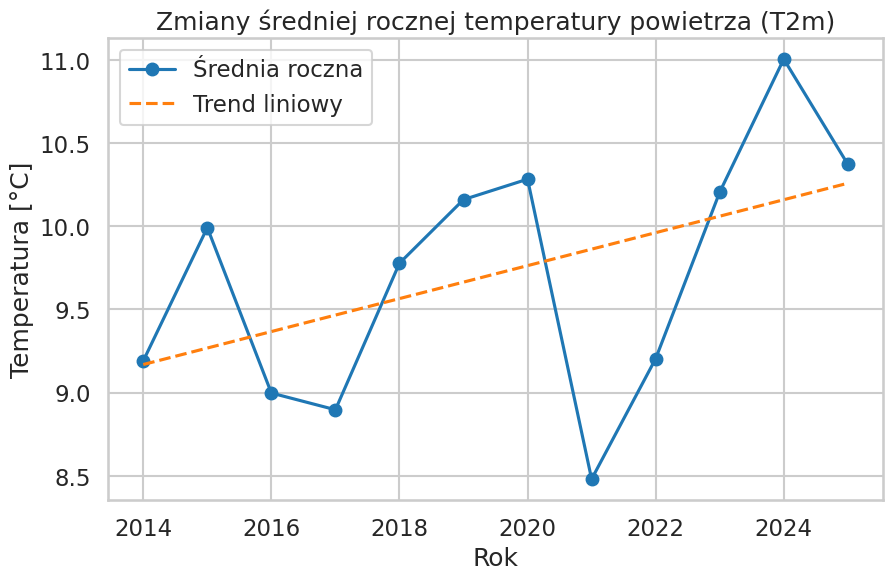

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(t2m_year["year"], t2m_year["t2m_year"], marker="o", label="Średnia roczna")
plt.plot(
    t2m_year["year"],
    res.intercept + res.slope * t2m_year["year"],
    linestyle="--",
    label="Trend liniowy"
)

plt.xlabel("Rok")
plt.ylabel("Temperatura [°C]")
plt.title("Zmiany średniej rocznej temperatury powietrza (T2m)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Podział na sezony
def get_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"

daily_area["season"] = daily_area["month"].apply(get_season)

daily_area["season_year"] = daily_area["year"]
daily_area.loc[daily_area["month"] == 12, "season_year"] += 1

In [ ]:
# Średnie sezonowe temperatury
t2m_season = (
    daily_area
    .groupby(["season_year", "season"], as_index=False)
    .agg(
        t2m_season=("t2m_day", "mean")
    )
)

t2m_season.head()

,season_year,season,t2m_season
0,2014,DJF,-2.053514
1,2014,JJA,19.014023
2,2014,MAM,10.388597
3,2014,SON,8.656528
4,2015,DJF,0.210844


In [ ]:
# Trend sezonowy
results = []

for season in ["DJF", "MAM", "JJA", "SON"]:
    df_s = t2m_season[t2m_season["season"] == season]

    x = df_s["season_year"].values
    y = df_s["t2m_season"].values

    res = linregress(x, y)

    results.append({
        "season": season,
        "trend_C_per_decade": res.slope * 10,
        "p_value": res.pvalue,
        "R2": res.rvalue**2
    })

season_trends = pd.DataFrame(results)
season_trends

,season,trend_C_per_decade,p_value,R2
0,DJF,2.677707,0.031961,0.353968
1,MAM,-0.383060,0.715901,0.013826
2,JJA,0.865236,0.176283,0.174749
3,SON,1.163746,0.126718,0.217219


In [ ]:
d = daily_area.copy()

# Wybranie ekstremów na podstawie kwartyli
p10 = d["t2m_day"].quantile(0.10)
p90 = d["t2m_day"].quantile(0.90)

print(f"P10 (bardzo chłodne dni): {p10:.2f} °C")
print(f"P90 (bardzo ciepłe dni): {p90:.2f} °C")


P10 (bardzo chłodne dni): -0.87 °C
P90 (bardzo ciepłe dni): 21.17 °C


In [ ]:
# Label ekstremów
d["hot_day"] = d["t2m_day"] > p90
d["cold_day"] = d["t2m_day"] < p10

d["hot_excess"] = np.where(d["hot_day"], d["t2m_day"] - p90, np.nan)
d["cold_excess"] = np.where(d["cold_day"], p10 - d["t2m_day"], np.nan)

d.head()

,date_ts,t2m_day,swvl2_day,n_points,year,month,season,season_year,hot_day,cold_day,hot_excess,cold_excess
0,2014-01-01,0.884125,0.315978,2,2014,1,DJF,2014,False,False,NaN,NaN
1,2014-01-02,1.412750,0.314478,2,2014,1,DJF,2014,False,False,NaN,NaN
2,2014-01-03,1.538467,0.313608,2,2014,1,DJF,2014,False,False,NaN,NaN
3,2014-01-04,3.149597,0.312448,2,2014,1,DJF,2014,False,False,NaN,NaN
4,2014-01-05,5.154007,0.313571,2,2014,1,DJF,2014,False,False,NaN,NaN


In [ ]:
# Agregacja występowania ekstremów temperaturowych
ext_year = (
    d.groupby("year", as_index=False)
     .agg(
         mean_t2m=("t2m_day", "mean"),
         n_hot=("hot_day", "sum"),
         n_cold=("cold_day", "sum"),
         n_days=("t2m_day", "count")
     )
)

ext_year.head()

,year,mean_t2m,n_hot,n_cold,n_days
0,2014,9.191186,39,47,365
1,2015,9.992112,37,25,365
2,2016,8.997866,26,37,366
3,2017,8.897282,19,37,365
4,2018,9.778069,56,64,365


In [ ]:
# Średnia temperatura w dniach ekstremalnych
hot_mean = d[d["hot_day"]].groupby("year")["t2m_day"].mean()
cold_mean = d[d["cold_day"]].groupby("year")["t2m_day"].mean()

ext_year["t2m_hot_mean"] = ext_year["year"].map(hot_mean)
ext_year["t2m_cold_mean"] = ext_year["year"].map(cold_mean)

In [ ]:
# Średnio jak bardzo został przekroczony próg do bycia ekstremum
hot_excess_mean = d.groupby("year")["hot_excess"].mean()
cold_excess_mean = d.groupby("year")["cold_excess"].mean()

ext_year["hot_excess_mean"] = ext_year["year"].map(hot_excess_mean)
ext_year["cold_excess_mean"] = ext_year["year"].map(cold_excess_mean)

ext_year

,year,mean_t2m,n_hot,n_cold,n_days,t2m_hot_mean,t2m_cold_mean,hot_excess_mean,cold_excess_mean
0,2014,9.191186,39,47,365,23.780169,-6.970649,2.606606,6.103254
1,2015,9.992112,37,25,365,24.457672,-3.091685,3.284110,2.224290
2,2016,8.997866,26,37,366,23.508413,-5.559446,2.334851,4.692051
3,2017,8.897282,19,37,365,23.461929,-6.181581,2.288368,5.314186
4,2018,9.778069,56,64,365,23.250107,-4.682120,2.076545,3.814725
5,2019,10.160482,38,32,365,23.644094,-4.433547,2.470532,3.566152
6,2020,10.283272,40,14,366,23.002176,-2.138607,1.828613,1.271212
7,2021,8.480567,37,60,365,24.244183,-5.909305,3.070621,5.041910
8,2022,9.204487,41,41,365,23.653357,-3.337614,2.479794,2.470219
9,2023,10.205269,32,35,365,23.470390,-3.181516,2.296827,2.314121


In [ ]:
# Trend częstości występowania ekstremów
def trend_ols(df, xcol, ycol):
    tmp = df[[xcol, ycol]].dropna()
    res = linregress(tmp[xcol].values, tmp[ycol].values)
    return res

res_hot = trend_ols(ext_year, "year", "n_hot")
res_cold = trend_ols(ext_year, "year", "n_cold")

print(f"Trend n_hot:  {res_hot.slope*10:.2f} dni/dekadę | p={res_hot.pvalue:.3f} | R²={res_hot.rvalue**2:.2f}")
print(f"Trend n_cold: {res_cold.slope*10:.2f} dni/dekadę | p={res_cold.pvalue:.3f} | R²={res_cold.rvalue**2:.2f}")

Trend n_hot:  0.56 dni/dekadę | p=0.954 | R²=0.00
Trend n_cold: -11.26 dni/dekadę | p=0.400 | R²=0.07


In [ ]:
# Trend temperatury w dniach ekstremalnych
res_hot_int = trend_ols(ext_year, "year", "t2m_hot_mean")
res_cold_int = trend_ols(ext_year, "year", "t2m_cold_mean")

print(f"Trend t2m_hot_mean:  {res_hot_int.slope*10:.2f} °C/dekadę | p={res_hot_int.pvalue:.3f}")
print(f"Trend t2m_cold_mean: {res_cold_int.slope*10:.2f} °C/dekadę | p={res_cold_int.pvalue:.3f}")

Trend t2m_hot_mean:  -0.44 °C/dekadę | p=0.225
Trend t2m_cold_mean: 1.54 °C/dekadę | p=0.234


In [ ]:
# Trend przekroczenia progu
res_hot_exc = trend_ols(ext_year, "year", "hot_excess_mean")
res_cold_exc = trend_ols(ext_year, "year", "cold_excess_mean")

print(f"Trend hot_excess_mean:  {res_hot_exc.slope*10:.2f} °C/dekadę | p={res_hot_exc.pvalue:.3f}")
print(f"Trend cold_excess_mean: {res_cold_exc.slope*10:.2f} °C/dekadę | p={res_cold_exc.pvalue:.3f}")

Trend hot_excess_mean:  -0.44 °C/dekadę | p=0.225
Trend cold_excess_mean: -1.54 °C/dekadę | p=0.234


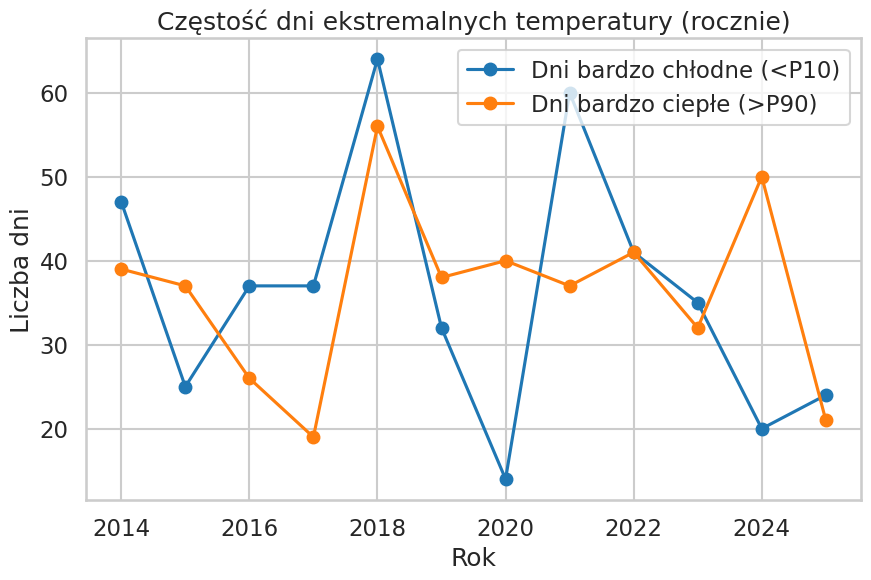

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(ext_year["year"], ext_year["n_cold"], marker="o", label="Dni bardzo chłodne (<P10)")
plt.plot(ext_year["year"], ext_year["n_hot"], marker="o", label="Dni bardzo ciepłe (>P90)")
plt.xlabel("Rok")
plt.ylabel("Liczba dni")
plt.title("Częstość dni ekstremalnych temperatury (rocznie)")
plt.grid(True)
plt.legend()
plt.show()

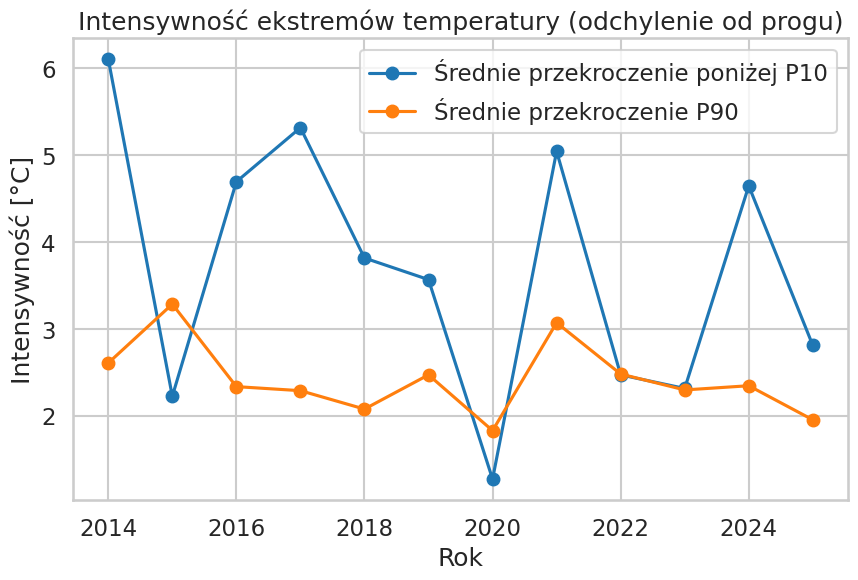

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(ext_year["year"], ext_year["cold_excess_mean"], marker="o", label="Średnie przekroczenie poniżej P10")
plt.plot(ext_year["year"], ext_year["hot_excess_mean"], marker="o", label="Średnie przekroczenie P90")
plt.xlabel("Rok")
plt.ylabel("Intensywność [°C]")
plt.title("Intensywność ekstremów temperatury (odchylenie od progu)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Miesięczne statystyki dla zmiennych chwilowych
monthly_inst = (
    daily_area
    .groupby(["year", "month"], as_index=False)
    .agg(
        t2m_month=("t2m_day", "mean"),
        d2m_month=("d2m_day", "mean"),
        skt_month=("skt_day", "mean"),
        swvl2_month=("swvl2_day", "mean"),
        n_days=("t2m_day", "count")
    )
)

In [ ]:
# Miesięczna suma dla promieniowania
df_acc["valid_time"] = pd.to_datetime(df_acc["valid_time"], utc=True, errors="coerce")
df_acc["year"] = df_acc["valid_time"].dt.year
df_acc["month"] = df_acc["valid_time"].dt.month

ssr_month_point = (
    df_acc
    .groupby(["year", "month", "point_id"], as_index=False)
    .agg(ssr_month_point=("ssr", "sum"))
)

ssr_month = (
    ssr_month_point
    .groupby(["year", "month"], as_index=False)
    .agg(ssr_month=("ssr_month_point", "mean"))
)

In [ ]:
# Merge w jedną tabelę z danymi miesięcznymi
monthly_diag = (
    monthly_inst
    .merge(ssr_month, on=["year", "month"], how="left")
    .merge(tp_month[["year", "month", "tp_month"]], on=["year", "month"], how="left")
)

# Oś czasu (dla wykresów)
monthly_diag["month_ts"] = pd.to_datetime(
    monthly_diag["year"].astype(str) + "-" + monthly_diag["month"].astype(str).str.zfill(2) + "-01",
    utc=True
)
monthly_diag = monthly_diag.sort_values("month_ts").reset_index(drop=True)

monthly_diag.head()

,year,month,t2m_month,d2m_month,skt_month,swvl2_month,n_days,ssr_month,tp_month,month_ts
0,2014,1,-4.619924,-6.950119,-4.769758,0.324933,31,8.678881,4.839659,2014-01-01 00:00:00+00:00
1,2014,2,0.787868,-1.875477,0.931848,0.324902,28,18.206367,3.027201,2014-02-01 00:00:00+00:00
2,2014,3,6.321167,1.315769,6.514099,0.307049,31,37.494461,4.267216,2014-03-01 00:00:00+00:00
3,2014,4,10.145982,3.321486,11.245113,0.267401,30,52.472961,2.518892,2014-04-01 00:00:00+00:00
4,2014,5,14.690813,8.293758,15.901571,0.257939,31,59.404831,9.504318,2014-05-01 00:00:00+00:00


In [ ]:
# Anomalie dla danych miesięcy

cols = ["t2m_month", "d2m_month", "skt_month", "swvl2_month", "ssr_month", "tp_month"]

clim = monthly_diag.groupby("month")[cols].mean()

anom = monthly_diag.copy()
for c in cols:
    anom[c + "_anom"] = anom.apply(lambda r: r[c] - clim.loc[r["month"], c], axis=1)

anom[["month_ts"] + [c + "_anom" for c in cols]].head()

,month_ts,t2m_month_anom,d2m_month_anom,skt_month_anom,swvl2_month_anom,ssr_month_anom,tp_month_anom
0,2014-01-01 00:00:00+00:00,-3.264571,-3.673051,-3.178690,-0.002497,-0.614301,0.334263
1,2014-02-01 00:00:00+00:00,0.340136,0.698339,0.329130,-0.005613,0.108253,-1.222988
2,2014-03-01 00:00:00+00:00,2.217330,2.447645,1.875236,-0.007713,1.458996,0.774085
3,2014-04-01 00:00:00+00:00,1.065372,1.292630,0.965266,-0.006943,0.289886,-2.370516
4,2014-05-01 00:00:00+00:00,0.291807,1.601242,-0.190117,0.022109,-6.784683,3.716052


In [ ]:
# Korelacje w anomaliach
def corr_report(df, x, y):
    tmp = df[[x, y]].dropna()
    r_p, p_p = pearsonr(tmp[x], tmp[y])
    r_s, p_s = spearmanr(tmp[x], tmp[y])
    return r_p, p_p, r_s, p_s, len(tmp)

pairs = [
    ("t2m_month_anom", "ssr_month_anom"),
    ("t2m_month_anom", "skt_month_anom"),
    ("t2m_month_anom", "d2m_month_anom"),
    ("t2m_month_anom", "swvl2_month_anom"),
    ("t2m_month_anom", "tp_month_anom"),
]

print("Korelacje na anomaliach miesięcznych (kontrola sezonowości):")
for x, y in pairs:
    r_p, p_p, r_s, p_s, n = corr_report(anom, x, y)
    print(f"- {x} vs {y}: Pearson r={r_p:.2f} (p={p_p:.3f}), Spearman ρ={r_s:.2f} (p={p_s:.3f}), n={n}")

Korelacje na anomaliach miesięcznych (kontrola sezonowości):
- t2m_month_anom vs ssr_month_anom: Pearson r=0.42 (p=0.000), Spearman ρ=0.40 (p=0.000), n=144
- t2m_month_anom vs skt_month_anom: Pearson r=0.99 (p=0.000), Spearman ρ=0.99 (p=0.000), n=144
- t2m_month_anom vs d2m_month_anom: Pearson r=0.82 (p=0.000), Spearman ρ=0.82 (p=0.000), n=144
- t2m_month_anom vs swvl2_month_anom: Pearson r=-0.19 (p=0.026), Spearman ρ=-0.14 (p=0.105), n=144
- t2m_month_anom vs tp_month_anom: Pearson r=-0.20 (p=0.015), Spearman ρ=-0.20 (p=0.015), n=144


In [ ]:
# Regresja wielowymiarowa na anomaliach
X_cols = ["ssr_month_anom", "swvl2_month_anom", "d2m_month_anom", "tp_month_anom"]
y_col = "t2m_month_anom"

reg_df = anom[[y_col] + X_cols].dropna().copy()

X = sm.add_constant(reg_df[X_cols])
y = reg_df[y_col]

model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         t2m_month_anom   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     601.4
Date:                Tue, 06 Jan 2026   Prob (F-statistic):           1.18e-86
Time:                        02:46:45   Log-Likelihood:                -109.46
No. Observations:                 144   AIC:                             228.9
Df Residuals:                     139   BIC:                             243.8
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1.163e-07      0.046  

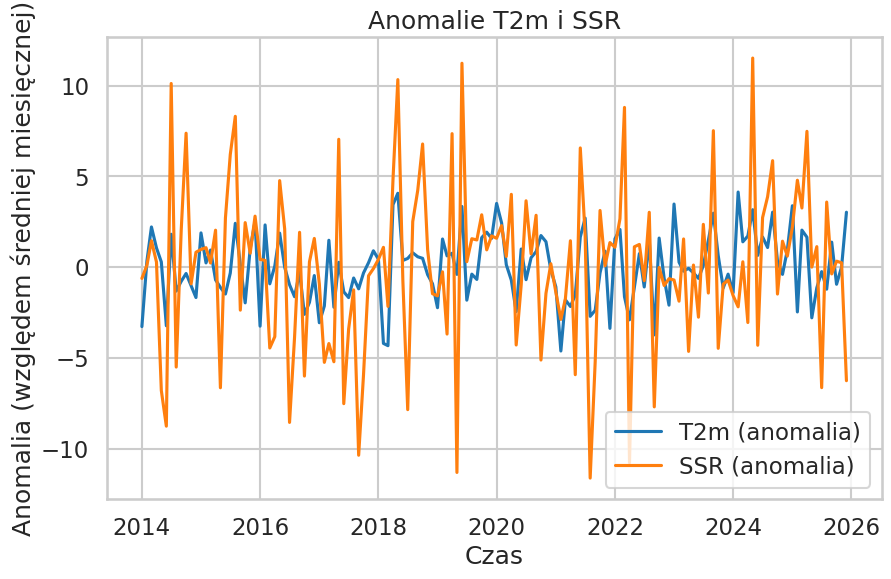

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(anom["month_ts"], anom["t2m_month_anom"], label="T2m (anomalia)")
plt.plot(anom["month_ts"], anom["ssr_month_anom"], label="SSR (anomalia)")
plt.xlabel("Czas")
plt.ylabel("Anomalia (względem średniej miesięcznej)")
plt.title("Anomalie T2m i SSR")
plt.grid(True)
plt.legend()
plt.show()